# Agentic Causal Discovery

**From a DataFrame to a causal graph in five steps — inspect, recommend, discover, interpret, and check.**

`causal-ts` recovers the *temporal causal graph* — who causes whom, and at which time lag — from multivariate time series. This tutorial walks the **agentic** workflow: let the library measure your data, recommend a configuration, run discovery, and read off the result.

This is exactly the workflow the **`causal-ts-discovery` agent skill** automates inside coding agents such as Claude Code and OpenAI Codex. Here we drive it directly in Python so you can see each step. The same calls are available on the command line:

```bash
causal-ts inspect data.csv          # data health + a recommended config
causal-ts discover data.csv --json  # run discovery, print the edge list
```

## Setup

```bash
pip install causalts
```

Everything below runs on CPU in a few seconds — no GPU required.

In [1]:
import warnings

# Two cosmetic, third-party warnings that don't affect results:
#  - PyTorch fires once when it wraps a read-only NumPy array;
#  - tqdm warns if ipywidgets is absent in the kernel.
warnings.filterwarnings('ignore', message='The given NumPy array is not writable')
warnings.filterwarnings('ignore', message='IProgress not found.*')

import json

import numpy as np
import pandas as pd

from causalts import inspect_df, discover_df, temporal_bootstrap
from causalts.inspection import edges_from_graph
from causalts.synthetic_data.synthetic_datasets import ex2
from causalts.utils.helpers import evaluate_graph

## 1. Load your data

Any *wide* table works: one **column per variable**, rows ordered in **time**, no index gymnastics required. Here we use a built-in six-node linear vector-autoregressive benchmark so that, at the end, we can score the recovered graph against a known ground truth.

In [2]:
data = ex2()          # a small, deterministic synthetic benchmark
df = data['df']

print(f"{data['name']}: {df.shape[0]} timesteps x {df.shape[1]} variables")
df.head()

6-Node Linear VAR: 300 timesteps x 6 variables


,X0,X1,X2,X3,X4,X5
0,0.925141,0.013994,-0.306749,-0.813984,1.960526,-1.308223
1,0.225846,-0.319118,0.481173,1.292313,1.681457,-0.591662
2,2.301345,0.056156,-0.538655,0.250631,0.296661,-0.382015
3,1.513349,-0.727234,-1.194538,0.815075,0.670917,-0.576091
4,0.404590,1.382834,0.026348,-0.216842,0.532288,-0.194573


## 2. Inspect — data health and a recommended configuration

`inspect_df` returns a single JSON-serializable report:

- **`data`** — shape, missing values, constant or discrete columns
- **`facts`** — measured properties: linearity, stationarity, a suggested maximum lag
- **`recommendation`** — an algorithm, a conditional-independence test, and a nonstationarity (C-node) preset, each justified in `rationale`
- **`cost_class`** — a rough compute estimate (`cheap` / `moderate` / `expensive`)
- **`warnings`** — data-health flags worth a human's attention

You are never obliged to follow the recommendation, but it is a sensible default derived from the data itself rather than a guess.

In [3]:
report = inspect_df(df)

print('cost_class:', report['cost_class'])
print('warnings :', report['warnings'] or 'none')
print('\nfacts:')
print(json.dumps(report['facts'], indent=2, default=str))
print('\nrecommendation:')
print(json.dumps(report['recommendation'], indent=2, default=str))

cost_class: cheap
warnings : none

facts:
{
  "linearity": {
    "fraction_nonlinear": 0.0,
    "is_nonlinear": false
  },
  "stationarity": {
    "fraction_nonstationary": 0.0,
    "nonstationary_cols": [],
    "form": "trend"
  },
  "suggested_max_lag": 4
}

recommendation:
{
  "algorithm": "cdnots",
  "ci_test": "parcorr-gpu",
  "include_C": false,
  "c_preset": "linear",
  "max_lag": 4,
  "params": {},
  "rationale": "moderate dimensionality (d=6) \u2192 CDNOTS; (Cedar is a good pairwise alternative); approximately linear \u2192 parcorr-gpu"
}


Reading the recommendation: a moderate number of variables (d = 6) points to **CDNOTS**; the series look approximately **linear**, so partial correlation (**parcorr-gpu**) is the fast, well-calibrated choice; and no clear nonstationarity was detected, so no time-index **C node** is added. The whole job is classified **cheap**.

## 3. Discover the causal graph

`discover_df` is the in-memory twin of the `causal-ts discover` command. We feed it the recommended configuration and get back a result object whose `.cg_tig` attribute is a `(d, d, max_lag + 1)` array where `cg_tig[cause, effect, lag]` marks an edge `cause(t - lag) -> effect(t)`.

We pass `return_pvals=True` so each edge carries the p-value that justified it. (This is off by default — on very high-dimensional data the full p-value matrix is a memory cost you opt into.)

In [4]:
rec = report['recommendation']

result = discover_df(
    df,
    algorithm=rec['algorithm'],
    ci_test=rec['ci_test'],
    max_lag=rec['max_lag'],
    include_C=rec['include_C'],
    c_preset=rec['c_preset'],
    return_pvals=True,
)

edges = edges_from_graph(result.cg_tig, list(df.columns), pvalue_matrix=result.pvalue_matrix)
print(f'discovered {len(edges)} directed edges (graph shape {result.cg_tig.shape})')

edge_table = pd.DataFrame(edges).sort_values(['lag', 'source', 'target'])
edge_table['pvalue'] = edge_table['pvalue'].map(lambda p: f'{p:.1e}')
edge_table.reset_index(drop=True)

discovered 8 directed edges (graph shape (6, 6, 5))


,source,target,lag,pvalue
0,X0,X0,1,3.2e-51
1,X3,X4,1,9.0e-60
2,X4,X3,1,6.7e-43
3,X5,X5,1,1.9e-47
4,X0,X1,2,6.7e-35
5,X0,X3,2,1.0e-42
6,X4,X5,2,4.6e-39
7,X0,X2,3,8.4e-24


Each row reads as **`source(t - lag) -> target(t)`**, with the p-value from the conditional-independence test that admitted it. For example, a row with `source=X0, target=X1, lag=2` means *X0 two steps ago drives X1 now*.

## 4. Visualize

The result object plots itself as a time-lagged causal graph, using a Graphviz **neato** spring layout by default (install `pygraphviz` for it; it falls back to a circular layout otherwise).

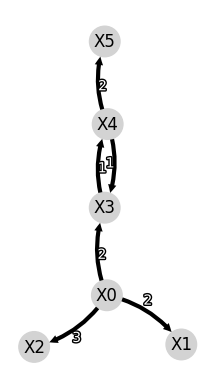

In [5]:
result.plot(var_names=list(df.columns));

## 5. Score against the ground truth

Because this dataset is synthetic, we know the true graph and can measure how well discovery did.

One detail: `inspect` suggested a maximum lag slightly larger than the benchmark's true lag, so the estimated graph has an extra (empty) lag slice. Searching a longer lag than the truth is harmless; we simply pad the ground truth with an empty slice so the two arrays line up.

In [6]:
gt = data['ground_truth']
gt_padded = np.zeros(result.cg_tig.shape, dtype=gt.dtype)
gt_padded[..., : gt.shape[2]] = gt

m = evaluate_graph(result.cg_tig, gt_padded)
print(f"Precision : {m['Precision']:.2f}   (fraction of found edges that are real)")
print(f"Recall    : {m['TPR']:.2f}   (fraction of real edges we found)")
print(f"F1        : {m['F1']:.2f}")
print(f"SHD       : {int(m['SHD'])}    (structural Hamming distance to truth)")

Precision : 1.00   (fraction of found edges that are real)
Recall    : 0.73   (fraction of real edges we found)
F1        : 0.84
SHD       : 3    (structural Hamming distance to truth)


Perfect precision (no spurious edges) and most of the real edges recovered — a healthy result for a constraint-based method on a short series.

## 6. Check stability when there is no ground truth

Real data has no answer key. The practical substitute is **stability**: re-run discovery on many contiguous sub-windows and see which edges keep reappearing. `temporal_bootstrap` does this and returns a `persistence` score per edge — the fraction of windows in which it was found. This is the same check behind `causal-ts discover --validate`.

Read it as a *robustness* signal, not a correctness proof: an edge driven by a systematic bias can be perfectly stable. High persistence means *not an artifact of which slice of time you happened to sample*.

In [7]:
def discovery_fn(sample):
    return discover_df(
        sample,
        algorithm=rec['algorithm'],
        ci_test=rec['ci_test'],
        max_lag=rec['max_lag'],
        include_C=rec['include_C'],
        c_preset=rec['c_preset'],
    ).cg_tig

boot = temporal_bootstrap(df, discovery_fn, n_bootstrap=20, window_frac=0.6, seed=0, show_progress=False)
pers = boot['persistence']
cols = list(df.columns)

stability = pd.DataFrame(
    [
        {
            'source': e['source'],
            'target': e['target'],
            'lag': e['lag'],
            'persistence': round(float(pers[cols.index(e['source']), cols.index(e['target']), e['lag']]), 2),
        }
        for e in edges
    ]
).sort_values('persistence', ascending=False)

print(f"bootstrap windows: {boot['n_success']} of 20 succeeded (window size {boot['window_size']})")
stability.reset_index(drop=True)

bootstrap windows: 20 of 20 succeeded (window size 180)


,source,target,lag,persistence
0,X0,X0,1,1.0
1,X0,X1,2,1.0
2,X0,X2,3,1.0
3,X0,X3,2,1.0
4,X3,X4,1,1.0
5,X4,X3,1,1.0
6,X4,X5,2,1.0
7,X5,X5,1,1.0


Here every edge persists across all windows — expected for a clean, strongly-linear synthetic signal. On noisy real data you will see a spread: the edges that recur in most sub-windows are the ones to trust first, while a low-persistence edge is a candidate for a closer look or a larger sample.

## Where to go next

- **Your own data:** swap `df` for any wide, time-ordered DataFrame, or point the CLI at a CSV/Parquet/Feather file.
- **From structure to effect size:** discovery answers *whether* X drives Y; estimating *how much* (ATE, counterfactuals) is a separate step via `pip install causalts[dowhy]` and `result.estimate_effect(...)`.
- **Let an agent drive it:** inside Claude Code or Codex, the `causal-ts-discovery` skill runs this entire inspect -> discover -> interpret loop from a plain-language request.